# 📊 News Content Analytics Dashboard
## V8 Scraped News Data Analysis

This notebook provides comprehensive analytics on the scraped news articles including:
- **Content Metrics**: Character count, word count, content length distribution
- **Keyword Analysis**: Frequency analysis, keyword co-occurrence, trending topics
- **Source Analysis**: Articles per source, method effectiveness
- **Temporal Analysis**: Publication patterns over time
- **Quality Metrics**: Content quality indicators, HTML cleanup analysis
- **Sentiment & Readability**: Article tone and complexity analysis

---

In [8]:
# ============================================================================
# CELL 1: IMPORT LIBRARIES & SETUP
# ============================================================================
import pandas as pd
import numpy as np
import re
from collections import Counter
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Libraries loaded successfully!")
print(f"📅 Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Libraries loaded successfully!
📅 Analysis Date: 2025-12-15 02:19:27


In [9]:
# ============================================================================
# CELL 2: LOAD DATA & INITIAL EXPLORATION
# ============================================================================
# Load the scraped news data
df = pd.read_csv('scraped_news_v8.csv')

print("=" * 70)
print("📰 NEWS DATA OVERVIEW")
print("=" * 70)
print(f"\n📊 Total Articles: {len(df):,}")
print(f"📁 Columns: {list(df.columns)}")
print(f"\n🔍 Data Types:")
print(df.dtypes)
print(f"\n📋 Sample Data:")
display(df.head(3))

📰 NEWS DATA OVERVIEW

📊 Total Articles: 433
📁 Columns: ['source', 'headline', 'author', 'url', 'published', 'matched_keywords', 'content_snippet', 'url_hash', 'full_content', 'method', 'scraped_at']

🔍 Data Types:
source               object
headline             object
author              float64
url                  object
published            object
matched_keywords     object
content_snippet      object
url_hash             object
full_content         object
method               object
scraped_at           object
dtype: object

📋 Sample Data:


,source,headline,author,url,published,matched_keywords,content_snippet,url_hash,full_content,method,scraped_at
0,The Next Web,Is ChatGPT’s New Shopping Research Solving a P...,NaN,https://thenextweb.com/news/is-chatgpts-new-sh...,2025-12-11T22:37:55,"chatgpt, openai, ev","<img height=""417"" src=""https://img-cdn.tnwcdn....",6a68b01f,"<img height=""417"" src=""https://img-cdn.tnwcdn....",rss,2025-12-15T01:04:45.047946
1,The Next Web,Tekpon acquires TNW (The Next Web) brand from ...,NaN,https://thenextweb.com/news/tekpon-acquires-tn...,2025-12-08T19:27:33,"startup, ev","<img height=""417"" src=""https://img-cdn.tnwcdn....",f70df2cb,"<img height=""417"" src=""https://img-cdn.tnwcdn....",rss,2025-12-15T01:04:45.048123
2,Digital Trends,Google is working on an Android feature to red...,NaN,https://www.digitaltrends.com/phones/google-is...,2025-12-14T07:26:49,ev,"<p>Android 17 may introduce Motion Cues, a sys...",5ab692cf,"<p>Android 17 may introduce Motion Cues, a sys...",rss,2025-12-15T01:04:47.095044


In [10]:
# ============================================================================
# CELL 3: TEXT CLEANING UTILITIES
# ============================================================================

def clean_html(text):
    """Remove HTML tags and entities from text"""
    if pd.isna(text):
        return ""
    text = str(text)
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    # Remove HTML entities
    text = re.sub(r'&[a-zA-Z]+;', ' ', text)
    text = re.sub(r'&#\d+;', ' ', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def extract_words(text):
    """Extract words from text (alphanumeric only)"""
    if pd.isna(text):
        return []
    text = clean_html(str(text).lower())
    words = re.findall(r'\b[a-zA-Z]{2,}\b', text)
    return words

def count_sentences(text):
    """Count sentences in text"""
    if pd.isna(text):
        return 0
    text = clean_html(str(text))
    sentences = re.split(r'[.!?]+', text)
    return len([s for s in sentences if s.strip()])

# Common English stopwords
STOPWORDS = {
    'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for',
    'of', 'with', 'by', 'from', 'as', 'is', 'was', 'are', 'were', 'been',
    'be', 'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would', 'could',
    'should', 'may', 'might', 'must', 'shall', 'can', 'need', 'dare', 'ought',
    'used', 'it', 'its', 'this', 'that', 'these', 'those', 'i', 'you', 'he',
    'she', 'we', 'they', 'what', 'which', 'who', 'whom', 'when', 'where',
    'why', 'how', 'all', 'each', 'every', 'both', 'few', 'more', 'most',
    'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same',
    'so', 'than', 'too', 'very', 'just', 'also', 'now', 'here', 'there',
    'then', 'once', 'if', 'because', 'until', 'while', 'about', 'into',
    'through', 'during', 'before', 'after', 'above', 'below', 'between',
    'under', 'again', 'further', 'any', 'up', 'down', 'out', 'off', 'over',
    'new', 'first', 'one', 'two', 'said', 'says', 'like', 'get', 'got',
    'make', 'made', 'us', 'our', 'your', 'their', 'his', 'her', 'my', 'me',
    'him', 'them', 'post', 'appeared', 'read', 'href', 'http', 'https', 'www',
    'com', 'html', 'img', 'src', 'amp', 'utm', 'source', 'medium', 'campaign'
}

print("✅ Text cleaning utilities defined!")
print(f"📝 Stopwords count: {len(STOPWORDS)}")

✅ Text cleaning utilities defined!
📝 Stopwords count: 147


In [11]:
# ============================================================================
# CELL 4: CONTENT METRICS CALCULATION
# ============================================================================
print("⏳ Calculating content metrics...")

# Calculate metrics for each article
df['raw_char_count'] = df['content'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)
df['clean_content'] = df['content'].apply(clean_html)
df['clean_char_count'] = df['clean_content'].apply(len)
df['word_count'] = df['clean_content'].apply(lambda x: len(x.split()))
df['sentence_count'] = df['content'].apply(count_sentences)
df['title_length'] = df['title'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)
df['title_word_count'] = df['title'].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)

# HTML ratio (how much was HTML vs actual content)
df['html_ratio'] = ((df['raw_char_count'] - df['clean_char_count']) / df['raw_char_count'] * 100).fillna(0)

# Average word length
df['avg_word_length'] = df['clean_content'].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0
)

# Unique word ratio
def unique_word_ratio(text):
    words = text.lower().split()
    if not words:
        return 0
    return len(set(words)) / len(words) * 100

df['unique_word_ratio'] = df['clean_content'].apply(unique_word_ratio)

print("✅ Content metrics calculated!")
print(f"\n📊 New columns added: {['raw_char_count', 'clean_content', 'clean_char_count', 'word_count', 'sentence_count', 'title_length', 'title_word_count', 'html_ratio', 'avg_word_length', 'unique_word_ratio']}")

⏳ Calculating content metrics...


KeyError: 'content'

In [ ]:
# ============================================================================
# CELL 5: CONTENT STATISTICS SUMMARY
# ============================================================================
print("=" * 70)
print("📊 CONTENT STATISTICS SUMMARY")
print("=" * 70)

# Summary statistics
stats_df = pd.DataFrame({
    'Metric': [
        'Raw Character Count',
        'Clean Character Count', 
        'Word Count',
        'Sentence Count',
        'Title Length (chars)',
        'Title Word Count',
        'HTML Ratio (%)',
        'Avg Word Length',
        'Unique Word Ratio (%)'
    ],
    'Min': [
        df['raw_char_count'].min(),
        df['clean_char_count'].min(),
        df['word_count'].min(),
        df['sentence_count'].min(),
        df['title_length'].min(),
        df['title_word_count'].min(),
        df['html_ratio'].min(),
        df['avg_word_length'].min(),
        df['unique_word_ratio'].min()
    ],
    'Max': [
        df['raw_char_count'].max(),
        df['clean_char_count'].max(),
        df['word_count'].max(),
        df['sentence_count'].max(),
        df['title_length'].max(),
        df['title_word_count'].max(),
        df['html_ratio'].max(),
        df['avg_word_length'].max(),
        df['unique_word_ratio'].max()
    ],
    'Mean': [
        df['raw_char_count'].mean(),
        df['clean_char_count'].mean(),
        df['word_count'].mean(),
        df['sentence_count'].mean(),
        df['title_length'].mean(),
        df['title_word_count'].mean(),
        df['html_ratio'].mean(),
        df['avg_word_length'].mean(),
        df['unique_word_ratio'].mean()
    ],
    'Median': [
        df['raw_char_count'].median(),
        df['clean_char_count'].median(),
        df['word_count'].median(),
        df['sentence_count'].median(),
        df['title_length'].median(),
        df['title_word_count'].median(),
        df['html_ratio'].median(),
        df['avg_word_length'].median(),
        df['unique_word_ratio'].median()
    ],
    'Std': [
        df['raw_char_count'].std(),
        df['clean_char_count'].std(),
        df['word_count'].std(),
        df['sentence_count'].std(),
        df['title_length'].std(),
        df['title_word_count'].std(),
        df['html_ratio'].std(),
        df['avg_word_length'].std(),
        df['unique_word_ratio'].std()
    ]
})

# Format numeric columns
for col in ['Min', 'Max', 'Mean', 'Median', 'Std']:
    stats_df[col] = stats_df[col].apply(lambda x: f"{x:,.1f}")

display(stats_df)

print(f"\n📝 Key Insights:")
print(f"   • Average article length: {df['word_count'].mean():.0f} words ({df['clean_char_count'].mean():.0f} chars)")
print(f"   • Average title length: {df['title_word_count'].mean():.1f} words")
print(f"   • Average HTML overhead: {df['html_ratio'].mean():.1f}%")
print(f"   • Content with <50 words: {len(df[df['word_count'] < 50])} articles ({len(df[df['word_count'] < 50])/len(df)*100:.1f}%)")
print(f"   • Content with >500 words: {len(df[df['word_count'] > 500])} articles ({len(df[df['word_count'] > 500])/len(df)*100:.1f}%)")

📊 CONTENT STATISTICS SUMMARY


,Metric,Min,Max,Mean,Median,Std
0,Raw Character Count,201.0,"61,084.0","4,455.0","2,286.0","6,178.0"
1,Clean Character Count,106.0,"61,084.0","4,024.7","2,057.0","5,561.7"
2,Word Count,19.0,"10,790.0",656.3,341.0,921.1
3,Sentence Count,2.0,730.0,35.6,18.0,54.3
4,Title Length (chars),15.0,200.0,69.4,67.0,25.4
5,Title Word Count,2.0,35.0,11.6,11.0,4.3
6,HTML Ratio (%),0.0,83.2,14.2,0.0,20.9
7,Avg Word Length,4.0,7.3,5.1,5.1,0.4
8,Unique Word Ratio (%),22.5,100.0,64.2,62.7,16.0



📝 Key Insights:
   • Average article length: 656 words (4025 chars)
   • Average title length: 11.6 words
   • Average HTML overhead: 14.2%
   • Content with <50 words: 57 articles (13.2%)
   • Content with >500 words: 180 articles (41.6%)


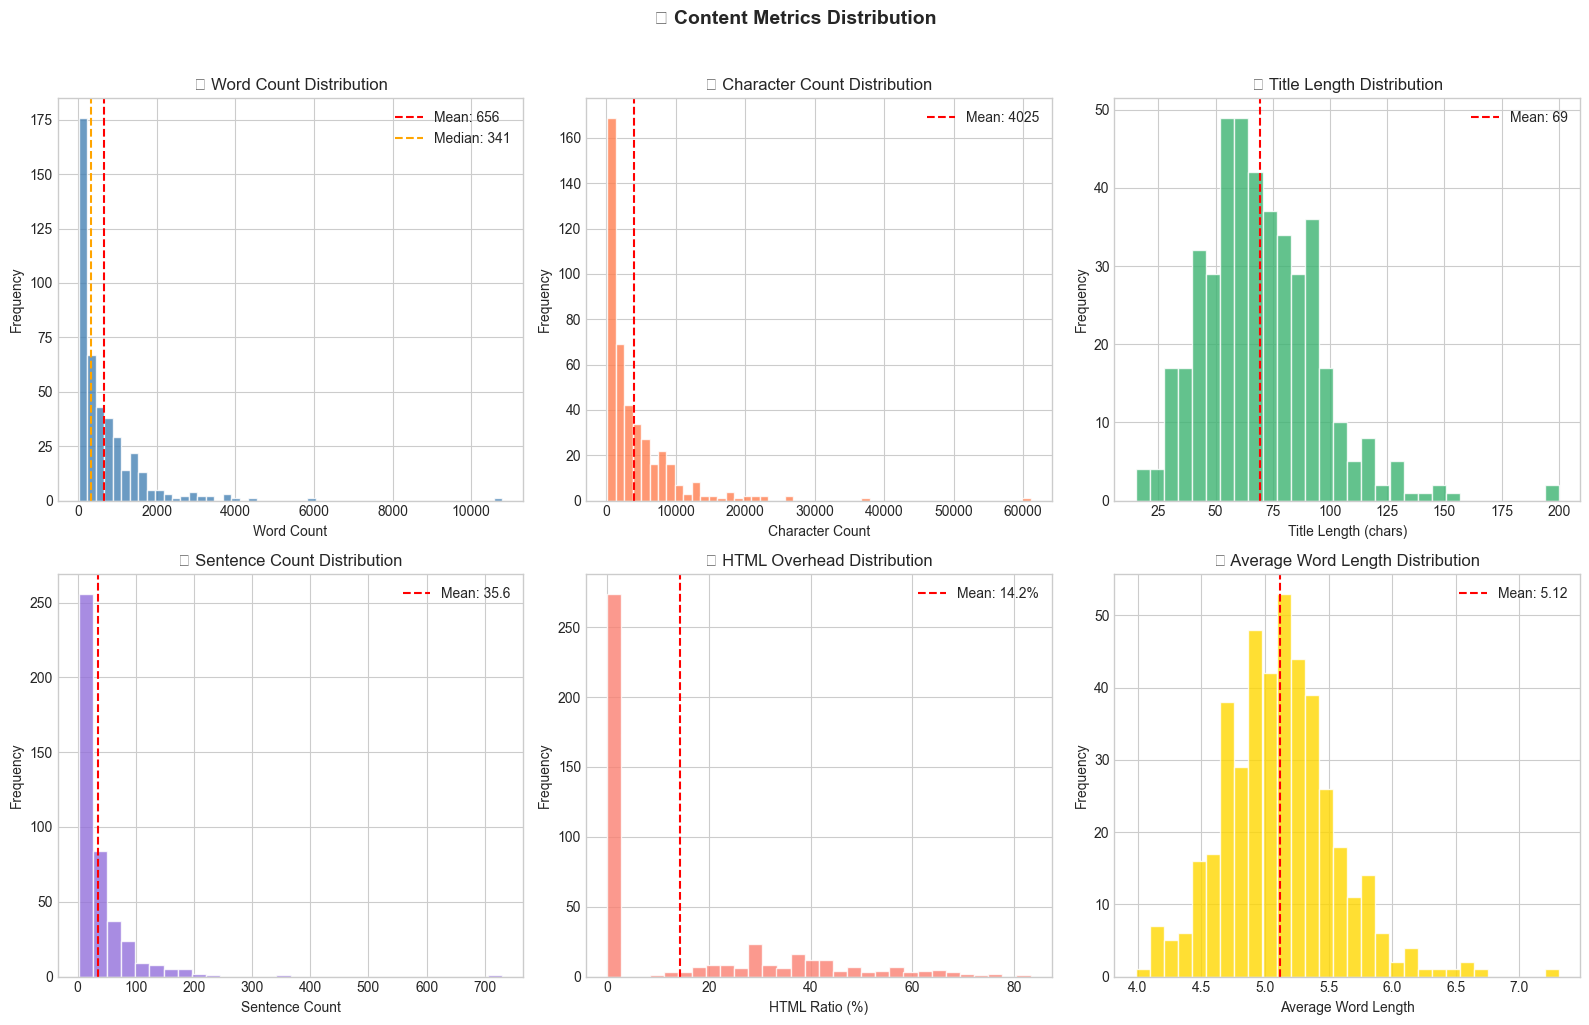

In [ ]:
# ============================================================================
# CELL 6: CONTENT LENGTH DISTRIBUTION VISUALIZATION
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Word Count Distribution
ax1 = axes[0, 0]
df['word_count'].hist(bins=50, ax=ax1, color='steelblue', edgecolor='white', alpha=0.8)
ax1.axvline(df['word_count'].mean(), color='red', linestyle='--', label=f'Mean: {df["word_count"].mean():.0f}')
ax1.axvline(df['word_count'].median(), color='orange', linestyle='--', label=f'Median: {df["word_count"].median():.0f}')
ax1.set_xlabel('Word Count')
ax1.set_ylabel('Frequency')
ax1.set_title('📝 Word Count Distribution')
ax1.legend()

# 2. Character Count Distribution
ax2 = axes[0, 1]
df['clean_char_count'].hist(bins=50, ax=ax2, color='coral', edgecolor='white', alpha=0.8)
ax2.axvline(df['clean_char_count'].mean(), color='red', linestyle='--', label=f'Mean: {df["clean_char_count"].mean():.0f}')
ax2.set_xlabel('Character Count')
ax2.set_ylabel('Frequency')
ax2.set_title('📏 Character Count Distribution')
ax2.legend()

# 3. Title Length Distribution
ax3 = axes[0, 2]
df['title_length'].hist(bins=30, ax=ax3, color='mediumseagreen', edgecolor='white', alpha=0.8)
ax3.axvline(df['title_length'].mean(), color='red', linestyle='--', label=f'Mean: {df["title_length"].mean():.0f}')
ax3.set_xlabel('Title Length (chars)')
ax3.set_ylabel('Frequency')
ax3.set_title('📰 Title Length Distribution')
ax3.legend()

# 4. Sentence Count Distribution
ax4 = axes[1, 0]
df['sentence_count'].hist(bins=30, ax=ax4, color='mediumpurple', edgecolor='white', alpha=0.8)
ax4.axvline(df['sentence_count'].mean(), color='red', linestyle='--', label=f'Mean: {df["sentence_count"].mean():.1f}')
ax4.set_xlabel('Sentence Count')
ax4.set_ylabel('Frequency')
ax4.set_title('📋 Sentence Count Distribution')
ax4.legend()

# 5. HTML Ratio Distribution
ax5 = axes[1, 1]
df['html_ratio'].hist(bins=30, ax=ax5, color='salmon', edgecolor='white', alpha=0.8)
ax5.axvline(df['html_ratio'].mean(), color='red', linestyle='--', label=f'Mean: {df["html_ratio"].mean():.1f}%')
ax5.set_xlabel('HTML Ratio (%)')
ax5.set_ylabel('Frequency')
ax5.set_title('🔧 HTML Overhead Distribution')
ax5.legend()

# 6. Average Word Length Distribution
ax6 = axes[1, 2]
df['avg_word_length'].hist(bins=30, ax=ax6, color='gold', edgecolor='white', alpha=0.8)
ax6.axvline(df['avg_word_length'].mean(), color='red', linestyle='--', label=f'Mean: {df["avg_word_length"].mean():.2f}')
ax6.set_xlabel('Average Word Length')
ax6.set_ylabel('Frequency')
ax6.set_title('🔤 Average Word Length Distribution')
ax6.legend()

plt.suptitle('📊 Content Metrics Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# CELL 7: KEYWORD ANALYSIS
# ============================================================================
print("=" * 70)
print("🔑 KEYWORD ANALYSIS")
print("=" * 70)

# 1. Matched Keywords from scraping
print("\n📌 Keywords Matched During Scraping:")
all_matched_keywords = []
for kw_str in df['keywords_matched'].dropna():
    if kw_str:
        keywords = [k.strip().lower() for k in str(kw_str).split(',')]
        all_matched_keywords.extend(keywords)

matched_keyword_counts = Counter(all_matched_keywords).most_common(20)
print("\nTop 20 Matched Keywords:")
for kw, count in matched_keyword_counts:
    bar = '█' * (count // 5) + '▌' * (1 if count % 5 >= 2 else 0)
    print(f"   {kw:20} : {count:4} │ {bar}")

# 2. Extract all words from content
print("\n📝 Extracting words from all article content...")
all_words = []
for content in df['clean_content']:
    words = [w.lower() for w in str(content).split() if len(w) >= 3]
    # Filter stopwords
    words = [w for w in words if w not in STOPWORDS]
    all_words.extend(words)

word_counts = Counter(all_words).most_common(30)

print("\nTop 30 Most Frequent Words (excluding stopwords):")
for word, count in word_counts:
    bar = '█' * (count // 20)
    print(f"   {word:20} : {count:5} │ {bar}")

🔑 KEYWORD ANALYSIS

📌 Keywords Matched During Scraping:

Top 20 Matched Keywords:
   ev                   :  392 │ ██████████████████████████████████████████████████████████████████████████████▌
   arm                  :  121 │ ████████████████████████
   intel                :   63 │ ████████████▌
   chip                 :   39 │ ███████▌
   openai               :   33 │ ██████▌
   tpu                  :   29 │ █████▌
   startup              :   27 │ █████▌
   battery              :   26 │ █████
   llm                  :   24 │ ████▌
   nvidia               :   23 │ ████▌
   semiconductor        :   23 │ ████▌
   chatgpt              :   20 │ ████
   artificial intelligence :   20 │ ████
   gemini               :   17 │ ███▌
   anthropic            :   16 │ ███
   generative ai        :   15 │ ███
   gpu                  :   14 │ ██▌
   solar                :   13 │ ██▌
   amd                  :   12 │ ██▌
   copilot              :   12 │ ██▌

📝 Extracting words from all article conte

In [ ]:
# ============================================================================
# CELL 8: KEYWORD VISUALIZATION
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 1. Matched Keywords Bar Chart
ax1 = axes[0]
if matched_keyword_counts:
    keywords_df = pd.DataFrame(matched_keyword_counts, columns=['Keyword', 'Count'])
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(keywords_df)))
    bars = ax1.barh(keywords_df['Keyword'], keywords_df['Count'], color=colors)
    ax1.invert_yaxis()
    ax1.set_xlabel('Count')
    ax1.set_title('🏷️ Top Matched Keywords (from scraping filter)')
    # Add value labels
    for bar, count in zip(bars, keywords_df['Count']):
        ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                f'{count}', va='center', fontsize=9)

# 2. Top Words from Content
ax2 = axes[1]
top_words_df = pd.DataFrame(word_counts[:20], columns=['Word', 'Count'])
colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(top_words_df)))
bars = ax2.barh(top_words_df['Word'], top_words_df['Count'], color=colors)
ax2.invert_yaxis()
ax2.set_xlabel('Count')
ax2.set_title('📊 Top 20 Words in Content (excluding stopwords)')
# Add value labels
for bar, count in zip(bars, top_words_df['Count']):
    ax2.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, 
            f'{count}', va='center', fontsize=9)

plt.suptitle('🔑 Keyword Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# CELL 9: SOURCE ANALYSIS
# ============================================================================
print("=" * 70)
print("📰 SOURCE ANALYSIS")
print("=" * 70)

# Articles per source
source_counts = df['source_name'].value_counts()

print("\n🏆 Top 15 Sources by Article Count:")
for source, count in source_counts.head(15).items():
    bar = '█' * count + ' '
    print(f"   {source:30} : {count:3} │ {bar}")

# Method distribution
print("\n\n🔧 Scraping Method Distribution:")
method_counts = df['method'].value_counts()
for method, count in method_counts.items():
    pct = count / len(df) * 100
    print(f"   {method.upper():12} : {count:4} articles ({pct:.1f}%)")

# Source by method
print("\n\n📊 Articles per Source (by Method):")
source_method = df.groupby(['source_name', 'method']).size().unstack(fill_value=0)
display(source_method.sort_values(by=source_method.columns.tolist(), ascending=False).head(15))

In [ ]:
# ============================================================================
# CELL 10: SOURCE VISUALIZATION
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Top Sources Bar Chart
ax1 = axes[0, 0]
top_sources = source_counts.head(15)
colors = plt.cm.Set3(np.linspace(0, 1, len(top_sources)))
bars = ax1.barh(top_sources.index, top_sources.values, color=colors)
ax1.invert_yaxis()
ax1.set_xlabel('Article Count')
ax1.set_title('🏆 Top 15 Sources by Article Count')
for bar, count in zip(bars, top_sources.values):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
            f'{count}', va='center', fontsize=9)

# 2. Method Distribution Pie Chart
ax2 = axes[0, 1]
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
explode = [0.02] * len(method_counts)
wedges, texts, autotexts = ax2.pie(method_counts.values, labels=method_counts.index.str.upper(), 
                                   autopct='%1.1f%%', colors=colors[:len(method_counts)],
                                   explode=explode, shadow=True)
ax2.set_title('🔧 Scraping Method Distribution')

# 3. Content Length by Source (Box Plot - top 10 sources)
ax3 = axes[1, 0]
top_10_sources = source_counts.head(10).index
df_top10 = df[df['source_name'].isin(top_10_sources)]
source_order = df_top10.groupby('source_name')['word_count'].median().sort_values(ascending=False).index
df_top10_sorted = df_top10.copy()
df_top10_sorted['source_name'] = pd.Categorical(df_top10_sorted['source_name'], categories=source_order, ordered=True)
sns.boxplot(data=df_top10_sorted, y='source_name', x='word_count', ax=ax3, palette='Set2')
ax3.set_xlabel('Word Count')
ax3.set_ylabel('Source')
ax3.set_title('📏 Content Length Distribution by Source (Top 10)')

# 4. Content Length by Method
ax4 = axes[1, 1]
sns.boxplot(data=df, x='method', y='word_count', ax=ax4, palette='Set1')
ax4.set_xlabel('Scraping Method')
ax4.set_ylabel('Word Count')
ax4.set_title('📊 Content Length by Scraping Method')

plt.suptitle('📰 Source & Method Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# CELL 11: TEMPORAL ANALYSIS
# ============================================================================
print("=" * 70)
print("📅 TEMPORAL ANALYSIS")
print("=" * 70)

# Parse dates
df['published_dt'] = pd.to_datetime(df['published_date'], errors='coerce')
df['scrape_dt'] = pd.to_datetime(df['scrape_timestamp'], errors='coerce')

# Extract date components
df['pub_date'] = df['published_dt'].dt.date
df['pub_hour'] = df['published_dt'].dt.hour
df['pub_dayofweek'] = df['published_dt'].dt.day_name()

# Date range
valid_dates = df['published_dt'].dropna()
if len(valid_dates) > 0:
    print(f"\n📆 Publication Date Range:")
    print(f"   • Earliest: {valid_dates.min().strftime('%Y-%m-%d %H:%M')}")
    print(f"   • Latest:   {valid_dates.max().strftime('%Y-%m-%d %H:%M')}")
    print(f"   • Span:     {(valid_dates.max() - valid_dates.min()).days} days")

# Articles by date
print(f"\n📊 Articles by Publication Date:")
date_counts = df['pub_date'].value_counts().sort_index()
for date, count in date_counts.tail(10).items():
    bar = '█' * count
    print(f"   {date} : {count:3} │ {bar}")

# Day of week distribution
print(f"\n📅 Articles by Day of Week:")
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = df['pub_dayofweek'].value_counts().reindex(dow_order, fill_value=0)
for day, count in dow_counts.items():
    bar = '█' * (count // 3)
    print(f"   {day:10} : {count:3} │ {bar}")

In [ ]:
# ============================================================================
# CELL 12: TEMPORAL VISUALIZATION
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Articles by Date
ax1 = axes[0, 0]
if len(date_counts) > 0:
    dates = [str(d) for d in date_counts.index]
    ax1.bar(range(len(dates)), date_counts.values, color='steelblue', alpha=0.8)
    ax1.set_xticks(range(len(dates)))
    ax1.set_xticklabels(dates, rotation=45, ha='right', fontsize=8)
    ax1.set_xlabel('Publication Date')
    ax1.set_ylabel('Article Count')
    ax1.set_title('📅 Articles by Publication Date')

# 2. Articles by Hour
ax2 = axes[0, 1]
hour_counts = df['pub_hour'].value_counts().sort_index()
hours = range(24)
counts = [hour_counts.get(h, 0) for h in hours]
ax2.bar(hours, counts, color='coral', alpha=0.8)
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Article Count')
ax2.set_title('⏰ Articles by Hour of Publication')
ax2.set_xticks(range(0, 24, 2))

# 3. Articles by Day of Week
ax3 = axes[1, 0]
colors = plt.cm.Set2(np.linspace(0, 1, 7))
bars = ax3.bar(dow_counts.index, dow_counts.values, color=colors)
ax3.set_xlabel('Day of Week')
ax3.set_ylabel('Article Count')
ax3.set_title('📆 Articles by Day of Week')
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 4. Heatmap: Source vs Day of Week
ax4 = axes[1, 1]
top_sources_temporal = source_counts.head(8).index
df_top_temp = df[df['source_name'].isin(top_sources_temporal)]
heatmap_data = df_top_temp.groupby(['source_name', 'pub_dayofweek']).size().unstack(fill_value=0)
# Reorder columns
heatmap_data = heatmap_data.reindex(columns=[d for d in dow_order if d in heatmap_data.columns], fill_value=0)
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', ax=ax4, cbar_kws={'label': 'Articles'})
ax4.set_title('🗓️ Source × Day of Week Heatmap')
ax4.set_xlabel('Day of Week')
ax4.set_ylabel('Source')

plt.suptitle('📅 Temporal Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# CELL 13: CONTENT QUALITY ANALYSIS
# ============================================================================
print("=" * 70)
print("✨ CONTENT QUALITY ANALYSIS")
print("=" * 70)

# Define quality thresholds
QUALITY_THRESHOLDS = {
    'min_words': 50,
    'max_html_ratio': 70,
    'min_sentences': 2,
    'ideal_word_range': (100, 2000)
}

# Calculate quality metrics
df['is_short'] = df['word_count'] < QUALITY_THRESHOLDS['min_words']
df['is_high_html'] = df['html_ratio'] > QUALITY_THRESHOLDS['max_html_ratio']
df['is_few_sentences'] = df['sentence_count'] < QUALITY_THRESHOLDS['min_sentences']
df['is_ideal_length'] = (df['word_count'] >= QUALITY_THRESHOLDS['ideal_word_range'][0]) & \
                        (df['word_count'] <= QUALITY_THRESHOLDS['ideal_word_range'][1])

# Quality score (simple heuristic)
df['quality_score'] = 100
df.loc[df['is_short'], 'quality_score'] -= 30
df.loc[df['is_high_html'], 'quality_score'] -= 20
df.loc[df['is_few_sentences'], 'quality_score'] -= 20
df.loc[~df['is_ideal_length'], 'quality_score'] -= 10

print(f"\n🎯 Quality Thresholds:")
print(f"   • Minimum words: {QUALITY_THRESHOLDS['min_words']}")
print(f"   • Maximum HTML ratio: {QUALITY_THRESHOLDS['max_html_ratio']}%")
print(f"   • Minimum sentences: {QUALITY_THRESHOLDS['min_sentences']}")
print(f"   • Ideal word range: {QUALITY_THRESHOLDS['ideal_word_range'][0]}-{QUALITY_THRESHOLDS['ideal_word_range'][1]}")

print(f"\n📊 Quality Distribution:")
print(f"   • Short articles (<{QUALITY_THRESHOLDS['min_words']} words): {df['is_short'].sum()} ({df['is_short'].mean()*100:.1f}%)")
print(f"   • High HTML ratio (>{QUALITY_THRESHOLDS['max_html_ratio']}%): {df['is_high_html'].sum()} ({df['is_high_html'].mean()*100:.1f}%)")
print(f"   • Few sentences (<{QUALITY_THRESHOLDS['min_sentences']}): {df['is_few_sentences'].sum()} ({df['is_few_sentences'].mean()*100:.1f}%)")
print(f"   • Ideal length articles: {df['is_ideal_length'].sum()} ({df['is_ideal_length'].mean()*100:.1f}%)")

print(f"\n⭐ Quality Score Distribution:")
quality_bins = [(0, 50), (51, 70), (71, 90), (91, 100)]
quality_labels = ['Poor (0-50)', 'Fair (51-70)', 'Good (71-90)', 'Excellent (91-100)']
for (low, high), label in zip(quality_bins, quality_labels):
    count = len(df[(df['quality_score'] >= low) & (df['quality_score'] <= high)])
    pct = count / len(df) * 100
    bar = '█' * (count // 10)
    print(f"   {label:20} : {count:4} ({pct:5.1f}%) │ {bar}")

In [ ]:
# ============================================================================
# CELL 14: QUALITY VISUALIZATION
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Quality Score Distribution
ax1 = axes[0, 0]
df['quality_score'].hist(bins=20, ax=ax1, color='teal', edgecolor='white', alpha=0.8)
ax1.axvline(df['quality_score'].mean(), color='red', linestyle='--', 
            label=f'Mean: {df["quality_score"].mean():.1f}')
ax1.set_xlabel('Quality Score')
ax1.set_ylabel('Frequency')
ax1.set_title('⭐ Quality Score Distribution')
ax1.legend()

# 2. Quality Issues Breakdown
ax2 = axes[0, 1]
issues = ['Short Content', 'High HTML Ratio', 'Few Sentences', 'Outside Ideal Range']
issue_counts = [df['is_short'].sum(), df['is_high_html'].sum(), 
                df['is_few_sentences'].sum(), (~df['is_ideal_length']).sum()]
colors = ['#e74c3c', '#f39c12', '#9b59b6', '#3498db']
bars = ax2.bar(issues, issue_counts, color=colors, alpha=0.8)
ax2.set_ylabel('Article Count')
ax2.set_title('⚠️ Content Quality Issues')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=15, ha='right')
for bar, count in zip(bars, issue_counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
            f'{count}', ha='center', fontsize=10)

# 3. Quality Score by Source (Top 10)
ax3 = axes[1, 0]
source_quality = df.groupby('source_name')['quality_score'].mean().sort_values(ascending=False).head(10)
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(source_quality)))
bars = ax3.barh(source_quality.index, source_quality.values, color=colors)
ax3.invert_yaxis()
ax3.set_xlabel('Average Quality Score')
ax3.set_title('🏆 Top 10 Sources by Quality Score')
ax3.axvline(70, color='orange', linestyle='--', alpha=0.5, label='Good threshold (70)')
ax3.legend()

# 4. Quality Score by Method
ax4 = axes[1, 1]
method_quality = df.groupby('method')['quality_score'].agg(['mean', 'std', 'count'])
x_pos = range(len(method_quality))
bars = ax4.bar(x_pos, method_quality['mean'], yerr=method_quality['std'], 
               capsize=5, color=['#3498db', '#e74c3c', '#2ecc71'][:len(method_quality)], alpha=0.8)
ax4.set_xticks(x_pos)
ax4.set_xticklabels(method_quality.index.str.upper())
ax4.set_ylabel('Average Quality Score')
ax4.set_title('📊 Quality Score by Scraping Method')
ax4.axhline(70, color='orange', linestyle='--', alpha=0.5, label='Good threshold (70)')
ax4.legend()

plt.suptitle('✨ Content Quality Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# CELL 15: TITLE ANALYSIS
# ============================================================================
print("=" * 70)
print("📰 TITLE ANALYSIS")
print("=" * 70)

# Title patterns
df['has_question'] = df['title'].str.contains(r'\?', na=False)
df['has_number'] = df['title'].str.contains(r'\d+', na=False)
df['has_colon'] = df['title'].str.contains(r':', na=False)
df['is_all_caps_word'] = df['title'].str.contains(r'\b[A-Z]{2,}\b', na=False)

print(f"\n📝 Title Patterns:")
print(f"   • Titles with questions (?): {df['has_question'].sum()} ({df['has_question'].mean()*100:.1f}%)")
print(f"   • Titles with numbers: {df['has_number'].sum()} ({df['has_number'].mean()*100:.1f}%)")
print(f"   • Titles with colons (:): {df['has_colon'].sum()} ({df['has_colon'].mean()*100:.1f}%)")
print(f"   • Titles with acronyms: {df['is_all_caps_word'].sum()} ({df['is_all_caps_word'].mean()*100:.1f}%)")

# Title word frequency
print(f"\n🔤 Most Common Title Words:")
title_words = []
for title in df['title'].dropna():
    words = [w.lower() for w in str(title).split() if len(w) >= 3 and w.lower() not in STOPWORDS]
    title_words.extend(words)

title_word_counts = Counter(title_words).most_common(20)
for word, count in title_word_counts:
    bar = '█' * (count // 2)
    print(f"   {word:15} : {count:4} │ {bar}")

# Longest and shortest titles
print(f"\n📏 Title Length Extremes:")
print(f"\n   Longest titles:")
for _, row in df.nlargest(3, 'title_length').iterrows():
    print(f"   • [{row['title_length']} chars] {row['title'][:80]}...")
    
print(f"\n   Shortest titles:")
for _, row in df.nsmallest(3, 'title_length').iterrows():
    print(f"   • [{row['title_length']} chars] {row['title']}")

In [ ]:
# ============================================================================
# CELL 16: CORRELATION & SUMMARY VISUALIZATION
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Correlation Heatmap
ax1 = axes[0, 0]
numeric_cols = ['raw_char_count', 'clean_char_count', 'word_count', 'sentence_count', 
                'title_length', 'html_ratio', 'avg_word_length', 'unique_word_ratio', 'quality_score']
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=ax1, square=True, linewidths=0.5)
ax1.set_title('🔗 Feature Correlation Matrix')

# 2. Word Count vs Quality Score
ax2 = axes[0, 1]
ax2.scatter(df['word_count'], df['quality_score'], alpha=0.5, c=df['html_ratio'], 
            cmap='RdYlGn_r', s=30)
ax2.set_xlabel('Word Count')
ax2.set_ylabel('Quality Score')
ax2.set_title('📊 Word Count vs Quality Score\n(color = HTML ratio)')
plt.colorbar(ax2.collections[0], ax=ax2, label='HTML Ratio (%)')

# 3. Title Length vs Word Count
ax3 = axes[1, 0]
colors = df['method'].map({'rss': 'blue', 'html': 'red', 'homepage': 'green'}).fillna('gray')
ax3.scatter(df['title_length'], df['word_count'], alpha=0.5, c=colors, s=30)
ax3.set_xlabel('Title Length (chars)')
ax3.set_ylabel('Content Word Count')
ax3.set_title('📰 Title Length vs Content Length\n(color = method)')
# Add legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='RSS'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='HTML'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=8, label='Homepage')]
ax3.legend(handles=legend_elements, loc='upper right')

# 4. Summary Stats by Source (Heatmap)
ax4 = axes[1, 1]
top_sources_summary = source_counts.head(10).index
summary_data = df[df['source_name'].isin(top_sources_summary)].groupby('source_name').agg({
    'word_count': 'mean',
    'quality_score': 'mean',
    'html_ratio': 'mean',
    'sentence_count': 'mean'
}).round(1)
summary_normalized = (summary_data - summary_data.min()) / (summary_data.max() - summary_data.min())
sns.heatmap(summary_normalized, annot=summary_data.values, fmt='.0f', cmap='YlGnBu', 
            ax=ax4, cbar_kws={'label': 'Normalized Value'})
ax4.set_title('📈 Source Performance Metrics')
ax4.set_xlabel('Metric')

plt.suptitle('📊 Advanced Analytics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# CELL 17: FINAL SUMMARY REPORT
# ============================================================================
print("=" * 70)
print("📋 FINAL ANALYTICS SUMMARY REPORT")
print("=" * 70)

print(f"""
📰 DATASET OVERVIEW
{'─' * 50}
   Total Articles:        {len(df):,}
   Total Sources:         {df['source_name'].nunique()}
   Date Range:            {valid_dates.min().strftime('%Y-%m-%d')} to {valid_dates.max().strftime('%Y-%m-%d')}
   Scraping Methods:      {', '.join(df['method'].unique())}

📝 CONTENT METRICS
{'─' * 50}
   Avg Word Count:        {df['word_count'].mean():.0f} words
   Avg Character Count:   {df['clean_char_count'].mean():,.0f} chars
   Avg Sentences:         {df['sentence_count'].mean():.1f} sentences
   Avg Title Length:      {df['title_length'].mean():.0f} chars ({df['title_word_count'].mean():.1f} words)
   Avg HTML Overhead:     {df['html_ratio'].mean():.1f}%

⭐ QUALITY METRICS
{'─' * 50}
   Avg Quality Score:     {df['quality_score'].mean():.1f}/100
   High Quality (>70):    {len(df[df['quality_score'] > 70])} articles ({len(df[df['quality_score'] > 70])/len(df)*100:.1f}%)
   Short Content (<50w):  {df['is_short'].sum()} articles ({df['is_short'].mean()*100:.1f}%)
   Ideal Length:          {df['is_ideal_length'].sum()} articles ({df['is_ideal_length'].mean()*100:.1f}%)

🔑 KEYWORD INSIGHTS
{'─' * 50}
   Top Matched Keywords:  {', '.join([k for k, _ in matched_keyword_counts[:5]])}
   Top Content Words:     {', '.join([w for w, _ in word_counts[:5]])}
   Unique Vocabulary:     {len(set(all_words)):,} unique words

🏆 TOP PERFORMING SOURCES
{'─' * 50}""")

# Top sources by article count
for i, (source, count) in enumerate(source_counts.head(5).items(), 1):
    avg_quality = df[df['source_name'] == source]['quality_score'].mean()
    print(f"   {i}. {source}: {count} articles (Avg Quality: {avg_quality:.0f})")

print(f"""
📊 METHOD EFFECTIVENESS
{'─' * 50}""")
for method in df['method'].unique():
    method_df = df[df['method'] == method]
    print(f"   {method.upper():12}: {len(method_df):4} articles | Avg Words: {method_df['word_count'].mean():6.0f} | Quality: {method_df['quality_score'].mean():.0f}")

print(f"""
{'=' * 70}
✅ Analysis Complete! 
📁 Data saved to: scraped_news_v8.csv
📊 Analytics generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
{'=' * 70}
""")

In [ ]:
# ============================================================================
# CELL 18: EXPORT ANALYTICS DATA
# ============================================================================

# Export enriched dataset with all analytics columns
analytics_columns = [
    'title', 'url', 'published_date', 'source_name', 'method', 'keywords_matched',
    'title_length', 'title_word_count', 'raw_char_count', 'clean_char_count',
    'word_count', 'sentence_count', 'html_ratio', 'avg_word_length', 
    'unique_word_ratio', 'quality_score', 'is_short', 'is_ideal_length',
    'has_question', 'has_number', 'has_colon'
]

df_export = df[[col for col in analytics_columns if col in df.columns]]
df_export.to_csv('news_analytics_enriched.csv', index=False)

print("✅ Enriched analytics data exported to: news_analytics_enriched.csv")
print(f"   • Columns: {len(df_export.columns)}")
print(f"   • Rows: {len(df_export)}")

# Quick summary stats export
summary_stats = {
    'total_articles': len(df),
    'total_sources': df['source_name'].nunique(),
    'avg_word_count': df['word_count'].mean(),
    'avg_quality_score': df['quality_score'].mean(),
    'high_quality_pct': len(df[df['quality_score'] > 70]) / len(df) * 100,
    'rss_articles': len(df[df['method'] == 'rss']),
    'html_articles': len(df[df['method'] == 'html']),
    'homepage_articles': len(df[df['method'] == 'homepage'])
}

print("\n📊 Quick Stats:")
for key, value in summary_stats.items():
    if isinstance(value, float):
        print(f"   • {key}: {value:.2f}")
    else:
        print(f"   • {key}: {value}")